# Model Training & Evaluation

Notebook para entrenar y evaluar modelos de clasificación para la predicción de Churn.

**Modelos:** Logistic Regression, Random Forest, Naive Bayes, XGBoost, Gradient Boosting, KNN, SVM

**Métricas:** Recall, F1-Macro, AUC-ROC

**Validación:** Stratified K-Fold (5 folds)

**Optimización:** GridSearchCV

**Tracking:** MLflow

## 1. Configuración e Imports

In [1]:
import pandas as pd
import numpy as np
import os
import warnings
import mlflow
import mlflow.sklearn
import joblib
import xgboost
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.model_selection import StratifiedKFold, GridSearchCV
from sklearn.metrics import (
    recall_score, f1_score, roc_auc_score,
    confusion_matrix, classification_report
)
import matplotlib.pyplot as plt

warnings.filterwarnings('ignore')
print("✓ Imports completados")

C:\Users\andre\AppData\Local\Programs\Python\Python312\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
2026/09/24 20:48:30 INFO mlflow.agent.hint: Load the `instrumenting-with-mlflow-tracing` skill at C:\Users\andre\AppData\Local\Programs\Python\Python312\Lib\site-packages\mlflow\assistant\skills\instrumenting-with-mlflow-tracing\SKILL.md before writing any tracing code; it ships with this MLflow install. Set MLFLOW_DISABLE_AGENT_HINT=1 to silence this.


✓ Imports completados


In [2]:
project_root = os.path.abspath(os.path.join(os.getcwd(), "../../"))
db_path = os.path.join(project_root, "mlflow.db")

mlflow.set_tracking_uri(f"sqlite:///{db_path}")
mlflow.set_experiment("churn_prediction")
print(f"✓ MLflow configurado con SQLite: {db_path}")

✓ MLflow configurado con SQLite: D:\andre\Documents\UdeA\Churn-Prediction\mlflow.db


## 2. Carga de Datos

In [3]:
test_folder = '../data/resampled/original'
X_test = pd.read_csv(f'{test_folder}/X_test.csv')
y_test = pd.read_csv(f'{test_folder}/y_test.csv')['Churn']

print(f"Test set: {X_test.shape[0]} muestras, {X_test.shape[1]} features")
print(f"Distribución test:\n{y_test.value_counts()}")

Test set: 1407 muestras, 30 features
Distribución test:
Churn
0    1033
1     374
Name: count, dtype: int64


In [4]:
resampled_dir = '../data/resampled'
datasets = {}

for folder in sorted(os.listdir(resampled_dir)):
    if folder == 'original':
        continue
    path = os.path.join(resampled_dir, folder)
    if os.path.isdir(path) and 'X_train.csv' in os.listdir(path):
        X = pd.read_csv(f'{path}/X_train.csv')
        y = pd.read_csv(f'{path}/y_train.csv')['Churn']
        datasets[folder] = (X, y)
        print(f"✓ {folder}: {X.shape[0]} muestras, {X.shape[1]} features")

print(f"\nDatasets cargados: {list(datasets.keys())}")

✓ adasyn: 8292 muestras, 30 features
✓ random_over: 8260 muestras, 30 features
✓ random_under: 2990 muestras, 30 features
✓ smote: 8260 muestras, 30 features
✓ smote_enn: 4596 muestras, 30 features
✓ smote_tomek: 7506 muestras, 30 features

Datasets cargados: ['adasyn', 'random_over', 'random_under', 'smote', 'smote_enn', 'smote_tomek']


## 2.1 Comparación rápida con LazyPredict

LazyPredict entrena varios clasificadores con configuraciones base para obtener una referencia inicial antes de la optimización con GridSearchCV. Sirve para descartar familias de modelos que no son competitivas antes de gastar tiempo en los grids.

**Este ranking no es comparable con el de las secciones siguientes**, por dos razones:

1. `LazyClassifier.fit()` recibe el conjunto de prueba directamente, así que ordena los modelos por su desempeño **en test**. Las secciones 4 y 4.1 seleccionan por validación cruzada sobre el conjunto de entrenamiento.
2. Las columnas `F1 Score` y `Recall` de LazyPredict son **promedios ponderados** sobre ambas clases — nótese que `Recall` coincide con `Accuracy`. El resto del notebook usa F1-Macro y el recall de la clase churn, que son métricas distintas y más exigentes con la clase minoritaria.

Úsese como exploración, no como evidencia para elegir el modelo final.

In [5]:
from lazypredict.Supervised import LazyClassifier

# LazyPredict registra en MLflow cada clasificador que entrena (27 x 6 datasets = 162 runs).
# Se aisla en su propio experimento para no sepultar los runs de GridSearchCV.
mlflow.set_experiment('churn_lazypredict')

lazy_results = []

for dataset_name, (X_train, y_train) in datasets.items():
    lazy_classifier = LazyClassifier(
        verbose=0,
        ignore_warnings=True,
        custom_metric=None
    )
    lazy_models, _ = lazy_classifier.fit(X_train, X_test, y_train, y_test)
    lazy_models = lazy_models.reset_index().rename(columns={'index': 'Model'})
    lazy_models.insert(0, 'Dataset', dataset_name)
    lazy_results.append(lazy_models)

mlflow.set_experiment('churn_prediction')  # restaurar para el resto del notebook

lazypredict_results = pd.concat(lazy_results, ignore_index=True)
lazypredict_results = lazypredict_results.sort_values(
    ['Dataset', 'F1 Score'], ascending=[True, False]
)

os.makedirs('../data/results', exist_ok=True)
lazypredict_results.to_csv('../data/results/lazypredict_results.csv', index=False)

print('Resultados LazyPredict:')
print(lazypredict_results.to_string(index=False))

2026/09/24 22:51:05 INFO mlflow.tracking.fluent: Autologging successfully enabled for sklearn.


2026/09/24 22:51:05 INFO mlflow.tracking.fluent: Autologging successfully enabled for xgboost.


2026/09/24 22:51:07 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


2026/09/24 22:51:19 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


2026/09/24 22:51:22 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


...

2026/09/24 23:29:09 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


2026/09/24 23:29:19 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


2026/09/24 23:29:25 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


2026/09/24 23:29:37 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


Resultados LazyPredict:
     Dataset                         Model  Accuracy  Balanced Accuracy  ROC AUC  F1 Score  Precision   Recall  Time Taken
      adasyn        CalibratedClassifierCV  0.779673           0.726285 0.818094  0.781465   0.783591 0.779673    8.183439
      adasyn                           SVC  0.769012           0.730965 0.801269  0.774351   0.782843 0.769012   24.198332
      adasyn            LogisticRegression  0.767591           0.736820 0.818342  0.774203   0.785964 0.767591    7.732123
      adasyn                     LinearSVC  0.764748           0.739148 0.818886  0.772334   0.786918 0.764748    7.438259
      adasyn                 SGDClassifier  0.764748           0.717826 0.810839  0.768803   0.774469 0.764748    7.553100
      adasyn        RandomForestClassifier  0.764037           0.715637 0.807072  0.767861   0.773088 0.764037    8.718386
      adasyn            CatBoostClassifier  0.759773           0.720408 0.814876  0.765548   0.774711 0.759773   12

## 3. Definición de Modelos y Hiperparámetros

In [6]:
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

models = {
    'LogisticRegression': LogisticRegression(max_iter=1000, random_state=42),
    'RandomForest': RandomForestClassifier(random_state=42),
    'NaiveBayes': GaussianNB(),
    'XGBoost': xgboost.XGBClassifier(random_state=42, eval_metric='logloss'),
    'GradientBoosting': GradientBoostingClassifier(random_state=42),
    # KNN y SVM dependen de la escala: van en Pipeline con StandardScaler
    'KNN': Pipeline([('scaler', StandardScaler()), ('clf', KNeighborsClassifier())]),
    'SVM': Pipeline([('scaler', StandardScaler()), ('clf', SVC(probability=True, random_state=42))])
}

print(f"Modelos definidos: {list(models.keys())}")

Modelos definidos: ['LogisticRegression', 'RandomForest', 'NaiveBayes', 'XGBoost', 'GradientBoosting', 'KNN', 'SVM']


In [7]:
param_grids = {
    'LogisticRegression': {
        'C': [0.01, 0.1, 1, 10],
        'penalty': ['l1', 'l2'],
        'solver': ['liblinear']
    },
    'RandomForest': {
        'n_estimators': [100, 200, 300],
        'max_depth': [5, 10, 20, None],
        'min_samples_split': [2, 5, 10]
    },
    'NaiveBayes': {
        'var_smoothing': [1e-9, 1e-8, 1e-7, 1e-6]
    },
    'XGBoost': {
        'n_estimators': [100, 200, 300],
        'max_depth': [3, 5, 7],
        'learning_rate': [0.01, 0.1, 0.2],
        'subsample': [0.8, 1.0]
    },
    'GradientBoosting': {
        'n_estimators': [100, 200, 300],
        'max_depth': [3, 5, 7],
        'learning_rate': [0.01, 0.1, 0.2]
    },
    'KNN': {
        'clf__n_neighbors': [3, 5, 7, 9, 11, 15],
        'clf__weights': ['uniform', 'distance'],
        'clf__metric': ['euclidean', 'manhattan']
    },
    'SVM': [
        {'clf__kernel': ['rbf'], 'clf__C': [0.1, 1, 10], 'clf__gamma': ['scale', 0.01, 0.1]},
        {'clf__kernel': ['linear'], 'clf__C': [0.1, 1, 10]}
    ]
}

print("Hiperparámetros definidos para cada modelo")

Hiperparámetros definidos para cada modelo


## 4. Entrenamiento con GridSearchCV + MLflow

In [8]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
results = []

total = len(datasets) * len(models)
current = 0

for dataset_name, (X_train, y_train) in datasets.items():
    for model_name, model in models.items():
        current += 1
        print(f"\n{'='*60}")
        print(f"[{current}/{total}] Dataset: {dataset_name} | Modelo: {model_name}")
        print(f"{'='*60}")

        with mlflow.start_run(run_name=f"{dataset_name}_{model_name}"):
            mlflow.log_param("dataset", dataset_name)
            mlflow.log_param("model", model_name)
            mlflow.log_param("train_samples", X_train.shape[0])
            mlflow.log_param("features", X_train.shape[1])

            grid_search = GridSearchCV(
                model,
                param_grids[model_name],
                cv=cv,
                scoring='f1_macro',
                n_jobs=-1,
                verbose=0
            )
            grid_search.fit(X_train, y_train)

            mlflow.log_params(grid_search.best_params_)

            best_model = grid_search.best_estimator_
            y_pred = best_model.predict(X_test)
            y_proba = best_model.predict_proba(X_test)[:, 1]

            recall = recall_score(y_test, y_pred)
            f1 = f1_score(y_test, y_pred, average='macro')
            auc_roc = roc_auc_score(y_test, y_proba)

            mlflow.log_metric("recall", recall)
            mlflow.log_metric("f1_macro", f1)
            mlflow.log_metric("auc_roc", auc_roc)
            mlflow.log_metric("best_cv_score", grid_search.best_score_)

            artifact_name = f"{dataset_name}_{model_name}".replace(" ", "_")
            mlflow.sklearn.log_model(
                best_model,
                artifact_path=artifact_name,
                serialization_format=mlflow.sklearn.SERIALIZATION_FORMAT_CLOUDPICKLE,
            )

            results.append({
                'Dataset': dataset_name,
                'Model': model_name,
                'Recall': recall,
                'F1-Macro': f1,
                'AUC-ROC': auc_roc,
                'Best_CV_F1_Macro': grid_search.best_score_,
                'Best_Params': str(grid_search.best_params_)
            })

            print(f"  ✓ Recall: {recall:.4f} | F1-Macro: {f1:.4f} | AUC-ROC: {auc_roc:.4f}")
            print(f"  ✓ Best CV F1-Macro: {grid_search.best_score_:.4f}")

print(f"\n{'='*60}")
print(f"✓ Entrenamiento completado: {len(results)} experimentos")
print(f"{'='*60}")


[1/42] Dataset: adasyn | Modelo: LogisticRegression


2026/09/24 20:48:41 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


2026/09/24 20:48:42 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


  ✓ Recall: 0.6684 | F1-Macro: 0.7207 | AUC-ROC: 0.8191
  ✓ Best CV F1-Macro: 0.8259

[2/42] Dataset: adasyn | Modelo: RandomForest


2026/09/24 20:49:20 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


...

2026/09/24 21:14:27 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


  ✓ Recall: 0.6898 | F1-Macro: 0.6908 | AUC-ROC: 0.7953
  ✓ Best CV F1-Macro: 0.8293

[42/42] Dataset: smote_tomek | Modelo: SVM


2026/09/24 21:16:13 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


2026/09/24 21:16:14 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


  ✓ Recall: 0.6738 | F1-Macro: 0.7274 | AUC-ROC: 0.8303
  ✓ Best CV F1-Macro: 0.8512

✓ Entrenamiento completado: 42 experimentos


## 4.1 Baseline: entrenamiento sin remuestrear

Los 42 experimentos anteriores usan solo datasets balanceados, asi que no permiten estimar cuanto aporto el remuestreo. Esta seccion entrena los mismos 7 modelos sobre el set de entrenamiento **original** (5625 muestras, sin balancear) con identico protocolo — mismos grids, `StratifiedKFold(5)`, `scoring='f1_macro'` y el mismo test set — para tener el punto de comparacion que falta.

In [9]:
# Baseline sin remuestreo: mismos 7 modelos, mismos grids, mismo protocolo de CV
X_train_orig = pd.read_csv('../data/resampled/original/X_train.csv')
y_train_orig = pd.read_csv('../data/resampled/original/y_train.csv')['Churn']

cv_orig = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
results_original = []

print(f"Train original: {X_train_orig.shape[0]} muestras, {X_train_orig.shape[1]} features (sin balancear)")
print(f"Distribucion:\n{y_train_orig.value_counts()}\n")

for i, (name_orig, model_orig) in enumerate(models.items(), 1):
    print(f"[{i}/{len(models)}] {name_orig:<20}", end=' ', flush=True)

    with mlflow.start_run(run_name=f"original_{name_orig}"):
        mlflow.log_param("dataset", "original")
        mlflow.log_param("model", name_orig)
        mlflow.log_param("train_samples", X_train_orig.shape[0])
        mlflow.log_param("features", X_train_orig.shape[1])

        gs_orig = GridSearchCV(
            model_orig,
            param_grids[name_orig],
            cv=cv_orig,
            scoring='f1_macro',
            n_jobs=-1,
            verbose=0
        )
        gs_orig.fit(X_train_orig, y_train_orig)
        mlflow.log_params(gs_orig.best_params_)

        best_orig = gs_orig.best_estimator_
        pred_orig = best_orig.predict(X_test)
        proba_orig = best_orig.predict_proba(X_test)[:, 1]

        rec_orig = recall_score(y_test, pred_orig)
        f1_orig = f1_score(y_test, pred_orig, average='macro')
        auc_orig = roc_auc_score(y_test, proba_orig)

        mlflow.log_metric("recall", rec_orig)
        mlflow.log_metric("f1_macro", f1_orig)
        mlflow.log_metric("auc_roc", auc_orig)
        mlflow.log_metric("best_cv_score", gs_orig.best_score_)
        mlflow.sklearn.log_model(
            best_orig,
            artifact_path=f"original_{name_orig}",
            serialization_format=mlflow.sklearn.SERIALIZATION_FORMAT_CLOUDPICKLE,
        )

        results_original.append({
            'Dataset': 'original',
            'Model': name_orig,
            'Recall': rec_orig,
            'F1-Macro': f1_orig,
            'AUC-ROC': auc_orig,
            'Best_CV_F1_Macro': gs_orig.best_score_,
            'Best_Params': str(gs_orig.best_params_)
        })

    print(f"Recall {rec_orig:.4f} | F1-Macro {f1_orig:.4f} | AUC-ROC {auc_orig:.4f}")

results_original_df = pd.DataFrame(results_original).sort_values('F1-Macro', ascending=False)
results_original_df.to_csv('../data/results/model_training_results_original.csv', index=False)

print(f"\n{'='*60}")
print("Baseline sin remuestreo, ordenado por F1-Macro:")
print(results_original_df[['Model', 'Recall', 'F1-Macro', 'AUC-ROC']].to_string(index=False))

Train original: 5625 muestras, 30 features (sin balancear)
Distribucion:
Churn
0    4130
1    1495
Name: count, dtype: int64

[1/7] LogisticRegression   

2026/09/24 22:06:10 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


2026/09/24 22:06:11 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


Recall 0.5749 | F1-Macro 0.7405 | AUC-ROC 0.8368
[2/7] RandomForest         

2026/09/24 22:06:41 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


...

2026/09/24 22:08:08 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


Recall 0.5749 | F1-Macro 0.7105 | AUC-ROC 0.8114
[7/7] SVM                  

2026/09/24 22:09:02 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


2026/09/24 22:09:02 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


Recall 0.5481 | F1-Macro 0.7270 | AUC-ROC 0.8274

Baseline sin remuestreo, ordenado por F1-Macro:
             Model   Recall  F1-Macro  AUC-ROC
LogisticRegression 0.574866  0.740469 0.836795
               SVM 0.548128  0.727024 0.827406
           XGBoost 0.529412  0.721179 0.840377
  GradientBoosting 0.516043  0.714939 0.840072
      RandomForest 0.497326  0.713588 0.834496
               KNN 0.574866  0.710473 0.811442
        NaiveBayes 0.622995  0.697308 0.793533


In [10]:
# Cuanto aporto el remuestreo: baseline original vs. mejor estrategia de cada modelo
# results_df se define en la seccion 5, posterior a esta celda: se usa lo que haya disponible
if 'results_df' in globals():
    resamp = results_df
elif 'results' in globals():
    resamp = pd.DataFrame(results)
else:
    resamp = pd.read_csv('../data/results/model_training_results.csv')

mejor_resamp = (resamp.loc[resamp.groupby('Model')['F1-Macro'].idxmax()]
                      .set_index('Model')[['Dataset', 'Recall', 'F1-Macro']]
                      .rename(columns={'Dataset': 'Mejor_estrategia',
                                       'Recall': 'Recall_resamp',
                                       'F1-Macro': 'F1_resamp'}))

base = (results_original_df.set_index('Model')[['Recall', 'F1-Macro']]
                           .rename(columns={'Recall': 'Recall_orig', 'F1-Macro': 'F1_orig'}))

comp = base.join(mejor_resamp)
comp['D_F1'] = comp['F1_resamp'] - comp['F1_orig']
comp['D_Recall'] = comp['Recall_resamp'] - comp['Recall_orig']
comp = comp.sort_values('D_F1', ascending=False).round(4)

print("Impacto del remuestreo (D = remuestreado - original):")
print(comp[['F1_orig', 'F1_resamp', 'D_F1', 'Recall_orig', 'Recall_resamp', 'D_Recall', 'Mejor_estrategia']].to_string())
print(f"\nGanancia media en F1-Macro: {comp['D_F1'].mean():+.4f}")
print(f"Ganancia media en Recall:   {comp['D_Recall'].mean():+.4f}")

Impacto del remuestreo (D = remuestreado - original):
                    F1_orig  F1_resamp    D_F1  Recall_orig  Recall_resamp  D_Recall Mejor_estrategia
Model                                                                                                
RandomForest         0.7136     0.7233  0.0097       0.4973         0.6337    0.1364            smote
GradientBoosting     0.7149     0.7192  0.0043       0.5160         0.7193    0.2032        smote_enn
SVM                  0.7270     0.7297  0.0027       0.5481         0.6711    0.1230            smote
XGBoost              0.7212     0.7186 -0.0026       0.5294         0.6337    0.1043            smote
NaiveBayes           0.6973     0.6859 -0.0114       0.6230         0.7727    0.1497        smote_enn
KNN                  0.7105     0.6986 -0.0118       0.5749         0.7299    0.1551            smote
LogisticRegression   0.7405     0.7272 -0.0133       0.5749         0.6631    0.0882            smote

Ganancia media en F1-Macro:

## 5. Evaluación en Test Set

In [11]:
results_df = pd.DataFrame(results)
results_df = results_df.sort_values('F1-Macro', ascending=False)

print("\n📊 Resultados ordenados por F1-Macro:")
print(results_df[['Dataset', 'Model', 'Recall', 'F1-Macro', 'AUC-ROC']].to_string(index=False))


📊 Resultados ordenados por F1-Macro:
     Dataset              Model   Recall  F1-Macro  AUC-ROC
       smote                SVM 0.671123  0.729686 0.828613
 smote_tomek                SVM 0.673797  0.727414 0.830275
       smote LogisticRegression 0.663102  0.727163 0.825610
       smote       RandomForest 0.633690  0.723269 0.820484
 random_over       RandomForest 0.598930  0.722810 0.813910
 smote_tomek LogisticRegression 0.657754  0.721711 0.828176
   smote_enn       RandomForest 0.737968  0.721621 0.824325
      adasyn                SVM 0.639037  0.721460 0.805258
      adasyn LogisticRegression 0.668449  0.720671 0.819064
   smote_enn   GradientBoosting 0.719251  0.719221 0.814875
       smote            XGBoost 0.633690  0.718618 0.819977
   smote_enn            XGBoost 0.711230  0.716855 0.820066
   smote_enn                SVM 0.724599  0.716007 0.832118
   smote_enn LogisticRegression 0.729947  0.714744 0.831575
      adasyn       RandomForest 0.644385  0.714380 0.807822
 s

In [12]:
best = results_df.iloc[0]
print(f"\n🏆 Mejor modelo: {best['Model']} con dataset {best['Dataset']}")
print(f"   Recall:    {best['Recall']:.4f}")
print(f"   F1-Macro:  {best['F1-Macro']:.4f}")
print(f"   AUC-ROC:   {best['AUC-ROC']:.4f}")


🏆 Mejor modelo: SVM con dataset smote
   Recall:    0.6711
   F1-Macro:  0.7297
   AUC-ROC:   0.8286


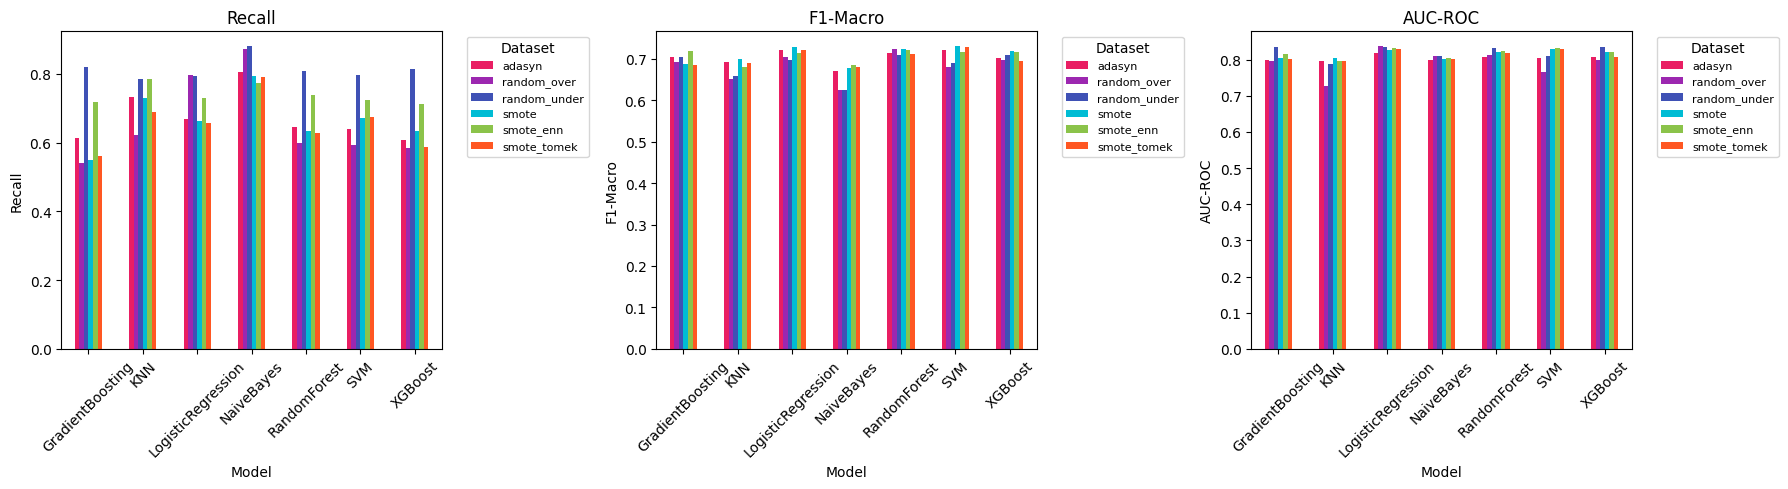

In [13]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

metrics = ['Recall', 'F1-Macro', 'AUC-ROC']
colors = ['#2196F3', '#4CAF50', '#FF9800']

for idx, metric in enumerate(metrics):
    pivot = results_df.pivot_table(index='Model', columns='Dataset', values=metric)
    pivot.plot(kind='bar', ax=axes[idx], color=['#E91E63', '#9C27B0', '#3F51B5', '#00BCD4', '#8BC34A', '#FF5722'])
    axes[idx].set_title(metric)
    axes[idx].set_ylabel(metric)
    axes[idx].tick_params(axis='x', rotation=45)
    axes[idx].legend(title='Dataset', bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=8)

plt.tight_layout()
plt.show()

## 6. Optimización de Threshold

In [14]:
best_model_name = best['Model']
best_dataset_name = best['Dataset']
best_params_str = best['Best_Params']

import ast
best_params = ast.literal_eval(best_params_str)

X_train_best, y_train_best = datasets[best_dataset_name]

final_model = models[best_model_name].set_params(**best_params)
final_model.fit(X_train_best, y_train_best)

y_proba = final_model.predict_proba(X_test)[:, 1]

print(f"Modelo final: {best_model_name} (Dataset: {best_dataset_name})")
print(f"Parámetros: {best_params}")

Modelo final: SVM (Dataset: smote)
Parámetros: {'clf__C': 10, 'clf__kernel': 'linear'}


In [15]:
thresholds = np.arange(0.1, 0.9, 0.05)
threshold_results = []

for t in thresholds:
    y_pred_t = (y_proba >= t).astype(int)
    threshold_results.append({
        'Threshold': round(t, 2),
        'Recall': recall_score(y_test, y_pred_t),
        'F1-Macro': f1_score(y_test, y_pred_t, average='macro'),
        'Predictions_Pos': y_pred_t.sum()
    })

threshold_df = pd.DataFrame(threshold_results)
print("\n📊 Métricas por Threshold:")
print(threshold_df.to_string(index=False))


📊 Métricas por Threshold:
 Threshold   Recall  F1-Macro  Predictions_Pos
      0.10 0.938503  0.589796              900
      0.15 0.911765  0.618524              834
      0.20 0.890374  0.648610              769
      0.25 0.863636  0.668833              714
      0.30 0.834225  0.689762              655
      0.35 0.780749  0.695729              597
      0.40 0.748663  0.708022              548
      0.45 0.719251  0.719221              503
      0.50 0.676471  0.728469              448
      0.55 0.639037  0.732172              406
      0.60 0.601604  0.737580              361
      0.65 0.513369  0.712318              307
      0.70 0.441176  0.693900              255
      0.75 0.347594  0.658997              196
      0.80 0.240642  0.610856              126
      0.85 0.131016  0.540820               63


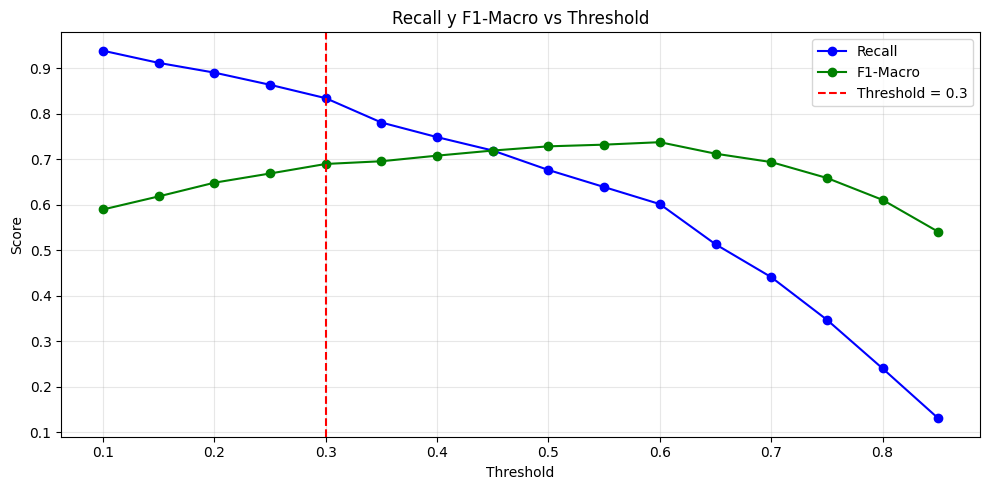

In [16]:
fig, ax1 = plt.subplots(figsize=(10, 5))

ax1.plot(threshold_df['Threshold'], threshold_df['Recall'], 'b-o', label='Recall')
ax1.plot(threshold_df['Threshold'], threshold_df['F1-Macro'], 'g-o', label='F1-Macro')
ax1.set_xlabel('Threshold')
ax1.set_ylabel('Score')
ax1.axvline(x=0.3, color='r', linestyle='--', label='Threshold = 0.3')
ax1.legend(loc='upper right')
ax1.set_title('Recall y F1-Macro vs Threshold')
ax1.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [17]:
THRESHOLD = 0.3
y_pred_final = (y_proba >= THRESHOLD).astype(int)

print(f"\n📊 Resultados con Threshold = {THRESHOLD}")
print(f"{'='*40}")
print(f"Recall:    {recall_score(y_test, y_pred_final):.4f}")
print(f"F1-Macro:  {f1_score(y_test, y_pred_final, average='macro'):.4f}")
print(f"AUC-ROC:   {roc_auc_score(y_test, y_proba):.4f}")
print(f"\nMatriz de Confusión:")
print(confusion_matrix(y_test, y_pred_final))
print(f"\nReporte de Clasificación:")
print(classification_report(y_test, y_pred_final, digits=4))


📊 Resultados con Threshold = 0.3
Recall:    0.8342
F1-Macro:  0.6898
AUC-ROC:   0.8286

Matriz de Confusión:
[[690 343]
 [ 62 312]]

Reporte de Clasificación:
              precision    recall  f1-score   support

           0     0.9176    0.6680    0.7731      1033
           1     0.4763    0.8342    0.6064       374

    accuracy                         0.7122      1407
   macro avg     0.6969    0.7511    0.6898      1407
weighted avg     0.8003    0.7122    0.7288      1407



## 7. Guardar Resultados

In [18]:
os.makedirs('../data/results', exist_ok=True)

results_df.to_csv('../data/results/model_training_results.csv', index=False)
print("✓ Resultados guardados en model_training_results.csv")

✓ Resultados guardados en model_training_results.csv


In [19]:
joblib.dump(final_model, f'../data/results/best_model_{best_model_name}.joblib')
print(f"✓ Mejor modelo guardado: best_model_{best_model_name}.joblib")

✓ Mejor modelo guardado: best_model_SVM.joblib


In [20]:
print(f"\n{'='*60}")
print(f"✓ PIPELINE COMPLETADO")
print(f"{'='*60}")
print(f"\nArchivos generados:")
print(f"  - ../data/results/model_training_results.csv")
print(f"  - ../data/results/best_model_{best_model_name}.joblib")
print(f"  - mlruns/ (MLflow experiments)")
print(f"\nPara ver MLflow UI ejecuta:")
print(f"  mlflow ui")


✓ PIPELINE COMPLETADO

Archivos generados:
  - ../data/results/model_training_results.csv
  - ../data/results/best_model_SVM.joblib
  - mlruns/ (MLflow experiments)

Para ver MLflow UI ejecuta:
  mlflow ui


## 8. Conclusiones

### Resumen: mejor configuración de cada modelo

| Modelo | Mejor estrategia | F1-Macro (remuestreado) | F1-Macro (original) | Δ | Recall (remuest.) | Recall (orig.) |
|---|---|---|---|---|---|---|
| **LogisticRegression** | smote | 0.7272 | **0.7405** | −0.0133 | 0.6631 | 0.5749 |
| SVM | smote | **0.7297** | 0.7270 | +0.0027 | 0.6711 | 0.5481 |
| RandomForest | smote | 0.7233 | 0.7136 | +0.0097 | 0.6337 | 0.4973 |
| XGBoost | smote | 0.7186 | 0.7212 | −0.0026 | 0.6337 | 0.5294 |
| GradientBoosting | smote_enn | 0.7192 | 0.7149 | +0.0043 | 0.7193 | 0.5160 |
| KNN | smote | 0.6986 | 0.7105 | −0.0118 | 0.7299 | 0.5749 |
| NaiveBayes | smote_enn | 0.6859 | 0.6973 | −0.0114 | 0.7727 | 0.6230 |

49 experimentos = 7 modelos x (6 estrategias de remuestreo + baseline sin remuestrear), con GridSearchCV (5-fold estratificado, `scoring='f1_macro'`) y evaluación sobre un test set único de 1407 muestras que nunca se remuestrea.

### Hallazgos

**1. El remuestreo compra recall a costa de precisión, y no mejora el F1-Macro.** Promediando los 7 modelos, pasar de datos originales a la mejor estrategia de remuestreo cambia el F1-Macro en **−0.0032** y el recall en **+0.1371**. Es decir: el balanceo funciona exactamente como se espera — detecta muchos más churners — pero no produce un clasificador globalmente mejor. En 4 de los 7 modelos el remuestreo incluso empeora el F1-Macro.

**2. El mejor F1-Macro de todo el estudio es un modelo sin remuestrear.** LogisticRegression sobre los datos originales alcanza **0.7405**, por encima del mejor resultado con remuestreo (SVM + SMOTE, 0.7297). La celda de selección automática (sección 5) solo considera los 42 experimentos remuestreados, así que **el `best_model_*.joblib` guardado no es el mejor modelo por F1-Macro**. Si el criterio de selección es F1-Macro, el ganador debería ser la Regresión Logística sin balancear.

**3. El mejor separador de estos datos es lineal.** El SVM ganador usa `kernel='linear'`, no rbf, y empata con la Regresión Logística, el otro modelo lineal del conjunto. Que dos métodos lineales independientes converjan al mismo techo, por encima de los cuatro modelos de árboles, sugiere que la frontera de decisión real es aproximadamente lineal en el espacio de features tras el one-hot encoding: no hay interacciones no lineales fuertes que los ensambles puedan explotar.

**4. Las diferencias entre los mejores modelos son un empate técnico.** Los primeros cinco puestos del ranking remuestreado caben en 0.0069 de F1-Macro, y la ventaja del baseline sin remuestrear sobre ellos es de 0.0108. Ambas diferencias son menores que la variabilidad esperable al cambiar la semilla del split. **No se debe afirmar que un modelo es mejor que otro sin repetir el experimento con varias semillas.**

**5. Entre las estrategias de remuestreo, SMOTE es la mejor y el sobremuestreo aleatorio la peor.** Promedio de F1-Macro por dataset: `smote` 0.7091, `smote_enn` 0.7077, `adasyn` 0.7038, `smote_tomek` 0.7015, `random_under` 0.6845, `random_over` 0.6814. Generar muestras sintéticas interpoladas supera tanto a duplicar registros como a descartar información de la clase mayoritaria.

**6. KNN rinde mal, y era previsible.** Sexto de siete con remuestreo, y con `random_over` cae al AUC más bajo de toda la tabla (0.7276). Con 30 features mayoritariamente binarias producto del one-hot encoding, las distancias euclidiana y manhattan pierden capacidad discriminante: la mayoría de las dimensiones solo aportan 0 o 1, y la distancia se satura.

**7. Recall y F1-Macro premian modelos distintos.** Si el criterio fuera solo recall, ganaría NaiveBayes con `random_under` (0.8797), pero su F1-Macro es el peor de la tabla (0.6248) porque inunda de falsos positivos. Conviene declarar explícitamente cuál de las dos métricas gobierna la decisión de negocio, porque llevan a modelos opuestos.

### Notas metodológicas

- **KNN y SVM van dentro de un `Pipeline` con `StandardScaler`.** Son los dos únicos modelos del conjunto sensibles a la escala, y `tenure`, `MonthlyCharges` y `TotalCharges` operan en rangos muy distintos. Sin estandarizar, sus resultados no serían comparables con el resto. Por eso sus hiperparámetros llevan el prefijo `clf__`.
- **El SVM requiere `probability=True`** porque el bucle de evaluación necesita `predict_proba` para el AUC-ROC. Esto añade una validación cruzada interna (Platt scaling) y multiplica por ~5 el tiempo de entrenamiento.
- **El threshold 0.3 está fijado a mano, no optimizado.** Con el SVM eleva el recall de 0.6711 a 0.8342, pero baja el F1-Macro de 0.7297 a 0.6898 y deja la precisión de la clase churn en 0.4763: de cada 100 clientes marcados como churn, ~52 no lo son. Es una decisión válida solo si el costo de perder un cliente supera claramente el de una retención innecesaria. El barrido de la sección 6 muestra que el óptimo de F1-Macro está más cerca de 0.5-0.6.
- **Ajustar el threshold y remuestrear persiguen el mismo objetivo.** Ambos desplazan el modelo hacia mayor recall. Aplicar los dos a la vez, como hace este notebook, duplica el efecto — y el resultado final (recall 0.8342, precisión de churn 0.4763) refleja esa acumulación más que el mérito del modelo.

### Siguientes pasos sugeridos

1. Repetir el top-3 con múltiples semillas para verificar si alguna de las diferencias observadas se sostiene.
2. Comparar el baseline sin remuestrear + ajuste de threshold contra el pipeline con remuestreo: si el threshold por sí solo consigue el mismo recall, el remuestreo es complejidad innecesaria.
3. Elegir el threshold a partir del costo real de un falso negativo frente a un falso positivo, en vez de fijarlo a 0.3.
4. Corregir la celda de selección automática para que considere también el baseline sin remuestrear, o dejar documentado que el modelo guardado es el mejor **entre los remuestreados**, no el mejor en absoluto.